LaTeX was requested but the current environment cannot compile a minimal TeX document. Falling back to Matplotlib serif text.
Totals per bar: [200 200 200 200 200 200]
Saved: /Users/zd3504phd/Desktop/XAIV/plots/5.4.1_dilation/cifar100_dilation_outcomes.pdf
Saved: /Users/zd3504phd/Desktop/XAIV/plots/5.4.1_dilation/cifar100_dilation_outcomes.png


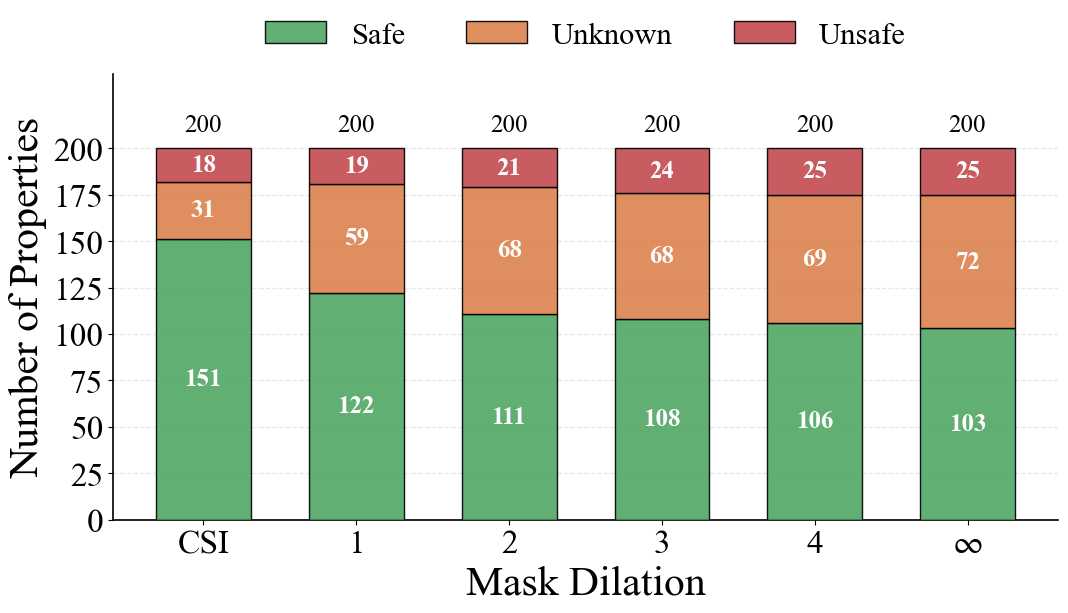

In [ ]:
import shutil
import subprocess
import tempfile
from functools import lru_cache
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
except ImportError:
    set_matplotlib_formats = None

FORCE_TEX = True
BASE_FONT_SIZE = 24
AXIS_LABEL_SIZE = 30
AXIS_TITLE_SIZE = 26
TICK_LABEL_SIZE = 24
LEGEND_FONT_SIZE = 22
VALUE_LABEL_FONT_SIZE = 18
DEFAULT_FIGSIZE = (11.2, 6.8)
RESULT_COLORS = {
    "safe": "#55A868",
    "unknown": "#DD8452",
    "unsafe": "#C44E52",
}


@lru_cache(maxsize=1)
def latex_ready():
    required_commands = ("latex", "dvipng")
    if any(shutil.which(command) is None for command in required_commands):
        return False

    if shutil.which("kpsewhich") is not None:
        latex_fmt = subprocess.run(
            ["kpsewhich", "latex.fmt"],
            capture_output=True,
            text=True,
            check=False,
        )
        if latex_fmt.returncode != 0 or not latex_fmt.stdout.strip():
            return False

    latex_source = "\n".join([
        r"\documentclass{article}",
        r"\begin{document}",
        r"lp",
        r"\end{document}",
    ])

    with tempfile.TemporaryDirectory() as tmpdir:
        tex_path = Path(tmpdir) / "matplotlib_tex_probe.tex"
        tex_path.write_text(latex_source, encoding="utf-8")
        result = subprocess.run(
            ["latex", "-interaction=nonstopmode", "--halt-on-error", tex_path.name],
            cwd=tmpdir,
            capture_output=True,
            text=True,
            check=False,
        )
        return result.returncode == 0 and (Path(tmpdir) / "matplotlib_tex_probe.dvi").exists()


def has_tex_package(package_name):
    if shutil.which("kpsewhich") is None:
        return False
    return subprocess.run(
        ["kpsewhich", f"{package_name}.sty"],
        capture_output=True,
        text=True,
        check=False,
    ).returncode == 0


def configure_plot_style(force_tex=FORCE_TEX):
    use_tex = force_tex and latex_ready()
    preamble = r"\usepackage{fontawesome5}" if use_tex and has_tex_package("fontawesome5") else ""

    if set_matplotlib_formats is not None:
        if use_tex and shutil.which("dvisvgm") is not None:
            set_matplotlib_formats("svg")
        else:
            set_matplotlib_formats("png")

    if force_tex and not use_tex:
        print("LaTeX was requested but the current environment cannot compile a minimal TeX document. Falling back to Matplotlib serif text.")

    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "text.latex.preamble": preamble,
        "font.size": BASE_FONT_SIZE,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "axes.titlesize": AXIS_TITLE_SIZE,
        "xtick.labelsize": TICK_LABEL_SIZE,
        "ytick.labelsize": TICK_LABEL_SIZE,
        "legend.fontsize": LEGEND_FONT_SIZE,
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    return use_tex


configure_plot_style()

if (Path("plots") / "5.4.1_dilation").exists():
    PLOT_DIR = Path("plots") / "5.4.1_dilation"
else:
    PLOT_DIR = Path.cwd()

PDF_OUTPUT_PATH = PLOT_DIR / "cifar100_dilation_outcomes.pdf"
PNG_OUTPUT_PATH = PLOT_DIR / "cifar100_dilation_outcomes.png"

# ============================================
# CIFAR-100 dilation results
# 0 = actual segmentation
# 1..4 = mask dilation radius
# inf = full / infinite dilation
# Total properties = 200
# ============================================

labels = ["CSI", "1", "2", "3", "4", r"$\infty$"]

# From your whiteboard
unknown = np.array([31, 59, 68, 68, 69, 72])
ce = np.array([18, 19, 21, 24, 25, 25])  # counterexamples / unsafe
safe = np.array([151, 122, 111, 108, 106, 103])

# Sanity check
totals = unknown + ce + safe
print("Totals per bar:", totals)  # should all be 200

x = np.arange(len(labels))
width = 0.62
ymax = int(totals.max())

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)

# Stacked bars
bars_safe = ax.bar(
    x,
    safe,
    width,
    label="Safe",
    color=RESULT_COLORS["safe"],
    edgecolor="black",
    linewidth=1.0,
    alpha=0.92,
    zorder=3,
)
bars_unk = ax.bar(
    x,
    unknown,
    width,
    bottom=safe,
    label="Unknown",
    color=RESULT_COLORS["unknown"],
    edgecolor="black",
    linewidth=1.0,
    alpha=0.92,
    zorder=3,
)
bars_ce = ax.bar(
    x,
    ce,
    width,
    bottom=safe + unknown,
    label="Unsafe",
    color=RESULT_COLORS["unsafe"],
    edgecolor="black",
    linewidth=1.0,
    alpha=0.92,
    zorder=3,
)

# Axis formatting
ax.set_ylim(0, ymax * 1.18 + 4)
ax.set_yticks(np.arange(0, 201, 25))
ax.set_ylabel("Number of Properties")
ax.set_xlabel("Mask Dilation")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
)
ax.grid(axis="y", linestyle="--", alpha=0.30)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Labels inside bars
def add_labels(bars, values, bottoms=None, text_color="white"):
    if bottoms is None:
        bottoms = np.zeros_like(values)
    for bar, val, bot in zip(bars, values, bottoms):
        if val <= 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bot + val / 2,
            f"{int(val)}",
            ha="center",
            va="center",
            fontsize=VALUE_LABEL_FONT_SIZE,
            fontweight="bold",
            color=text_color,
        )


add_labels(bars_safe, safe, text_color="white")
add_labels(bars_unk, unknown, bottoms=safe, text_color="white")
add_labels(bars_ce, ce, bottoms=safe + unknown, text_color="white")

# Total above each bar
for i, total in enumerate(totals):
    ax.text(
        x[i],
        total + 0.03 * ymax + 0.2,
        str(int(total)),
        ha="center",
        va="bottom",
        fontsize=VALUE_LABEL_FONT_SIZE,
    )

fig.tight_layout()
fig.savefig(PDF_OUTPUT_PATH, bbox_inches="tight")
# fig.savefig(PNG_OUTPUT_PATH, dpi=300, bbox_inches="tight")
print(f"Saved: {PDF_OUTPUT_PATH}")
# print(f"Saved: {PNG_OUTPUT_PATH}")
plt.show()
